CIS 509 Lab Assignment 1 - Text Processing Techniques
Matthew Cook (mcook20)
3/23/26


In [ ]:
# ============================================================
# Lab Assignment 1 — Text Processing Techniques
# CIS 509: Analytics for Unstructured Data
# Author: Matthew Cook
# ASU ID: [MCOOK20]
# Date Created: March 23, 2026
# ============================================================

# --- Library and data import ---

# Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')

# Import required libraries
import pandas as pd
import spacy
import nltk
from collections import Counter
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# --- Load the dataset ---
# Path: My Drive > Colab Notebooks > restaurant_reviews_az.csv
file_path = '/content/drive/MyDrive/Colab Notebooks/restaurant_reviews_az.csv'
df = pd.read_csv(file_path)

# --- Summary of input data ---

# Shape: rows and columns
print("=== Dataset Shape ===")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")

# Column names and data types
print("\n=== Column Names & Data Types ===")
print(df.dtypes)

# Null value check
print("\n=== Null Values Per Column ===")
print(df.isnull().sum())

# Star rating distribution
print("\n=== Star Rating Distribution ===")
print(df['stars'].value_counts().sort_index())

# Descriptive statistics
print("\n=== Descriptive Statistics ===")
print(df.describe(include='all'))

# Preview first 5 rows
print("\n=== First 5 Rows ===")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== Dataset Shape ===
Rows: 48,147  |  Columns: 9

=== Column Names & Data Types ===
review_id      object
user_id        object
business_id    object
stars           int64
useful          int64
funny           int64
cool            int64
text           object
date           object
dtype: object

=== Null Values Per Column ===
review_id      0
user_id        0
business_id    0
stars          0
useful         0
funny          0
cool           0
text           0
date           0
dtype: int64

=== Star Rating Distribution ===
stars
1     8466
2     3846
3     4054
4     7314
5    24467
Name: count, dtype: int64

=== Descriptive Statistics ===
       review_id user_id business_id         stars        useful  \
count      48147   48147       48147  48147.000000  48147.000000   
unique     47530   22435        1864           NaN           NaN   
top       #NAME?  #

,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,IVS7do_HBzroiCiymNdxDg,fdFgZQQYQJeEAshH4lxSfQ,sGy67CpJctjeCWClWqonjA,3,1,1,0,"OK, the hype about having Hatch chili in your ...",1/27/2020 22:59
1,QP2pSzSqpJTMWOCuUuyXkQ,JBLWSXBTKFvJYYiM-FnCOQ,3w7NRntdQ9h0KwDsksIt5Q,5,1,1,1,Pandemic pit stop to have an ice cream.... onl...,4/19/2020 5:33
2,oK0cGYStgDOusZKz9B1qug,2_9fKnXChUjC5xArfF8BLg,OMnPtRGmbY8qH_wIILfYKA,5,1,0,0,I was lucky enough to go to the soft opening a...,2/29/2020 19:43
3,E_ABvFCNVLbfOgRg3Pv1KQ,9MExTQ76GSKhxSWnTS901g,V9XlikTxq0My4gE8LULsjw,5,0,0,0,I've gone to claim Jumpers all over the US and...,3/14/2020 21:47
4,Rd222CrrnXkXukR2iWj69g,LPxuausjvDN88uPr-Q4cQA,CA5BOxKRDPGJgdUQ8OUOpw,4,1,0,0,"If you haven't been to Maynard's kitchen, it'...",1/17/2020 20:32


In [ ]:
# Code Cell 2 — Select 1-star and 5-star reviews

# Select all 1-star reviews from the dataset
df_1 = df[df['stars'] == 1]

# Select all 5-star reviews from the dataset
df_5 = df[df['stars'] == 5]

# Print count of 1-star reviews
print(f"1-star reviews:  {len(df_1):,}")

# Print count of 5-star reviews
print(f"5-star reviews:  {len(df_5):,}")

# Print total selected reviews
print(f"Total selected:  {len(df_1) + len(df_5):,}")

# Show star rating breakdown as a quick sanity check
print("\n=== Star Rating Distribution (full dataset) ===")
print(df['stars'].value_counts().sort_index())

# Preview one sample 1-star review text
print("\n=== Sample 1-Star Review ===")
print(df_1['text'].iloc[0][:300])

# Preview one sample 5-star review text
print("\n=== Sample 5-Star Review ===")
print(df_5['text'].iloc[0][:300])

1-star reviews:  8,466
5-star reviews:  24,467
Total selected:  32,933

=== Star Rating Distribution (full dataset) ===
stars
1     8466
2     3846
3     4054
4     7314
5    24467
Name: count, dtype: int64

=== Sample 1-Star Review ===
I stay at the Main Hotel at the Casino from July 11 to July 13; it was the WORST experience I've ever had.  For years I have supported this hotel and the casino; however, this time...it was a disaster. Will I go back, hopefullly, NO!

=== Sample 5-Star Review ===
Pandemic pit stop to have an ice cream.... only plain Sundae! Limited menu was written on the screens outside. So no unpleasant surprise.
Cashier was wearing gloves and mask, and him holding the item was good since he did not hold it with the lid. 
There were only three customers at 8:15 pm.
Locatio


In [ ]:
# Code Cell 3 — Full NLP Pipeline (spaCy)
# Techniques: Tokenization, Sentence Segmentation, POS Tagging,
#             Lemmatization, NER, Dependency Parsing
# Note: Coreference resolution intentionally excluded per assignment instructions

# --- Install and load spaCy model ---
!pip install -q spacy
!python -m spacy download en_core_web_sm -q

import spacy

# Load the English spaCy model
nlp = spacy.load("en_core_web_sm")

# ----------------------------------------------------------------
# Helper function: run the full pipeline on a list of review texts
# Returns a list of spaCy Doc objects
# ----------------------------------------------------------------
def run_pipeline(texts, label):
    print(f"\nProcessing {len(texts):,} {label} reviews through NLP pipeline...")
    docs = []
    for text in texts:
        if isinstance(text, str) and len(text.strip()) > 0:
            docs.append(nlp(text))
    print(f"  Done — {len(docs):,} docs created.")
    return docs

# ----------------------------------------------------------------
# Run pipeline on 1-star and 5-star review text columns
# ----------------------------------------------------------------
docs_1 = run_pipeline(df_1['text'].tolist(), "1-star")
docs_5 = run_pipeline(df_5['text'].tolist(), "5-star")

# ----------------------------------------------------------------
# TECHNIQUE 1 — TOKENIZATION
# Split each review into individual word/punctuation tokens
# ----------------------------------------------------------------
print("\n=== TOKENIZATION ===")
sample_doc = docs_1[0]
print(f"Sample 1-star review tokenized ({len(sample_doc)} tokens):")
print([token.text for token in sample_doc][:20], "...")

# ----------------------------------------------------------------
# TECHNIQUE 2 — SENTENCE SEGMENTATION
# Split each review into individual sentences
# ----------------------------------------------------------------
print("\n=== SENTENCE SEGMENTATION ===")
sample_sentences = list(sample_doc.sents)
print(f"Sample 1-star review — {len(sample_sentences)} sentence(s) detected:")
for i, sent in enumerate(sample_sentences[:3]):
    print(f"  Sentence {i+1}: {sent.text[:100]}")

# ----------------------------------------------------------------
# TECHNIQUE 3 — POS TAGGING
# Assign a grammatical part-of-speech tag to each token
# -------------------------------------

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.

Processing 8,466 1-star reviews through NLP pipeline...
  Done — 8,466 docs created.

Processing 24,467 5-star reviews through NLP pipeline...
  Done — 24,467 docs created.

=== TOKENIZATION ===
Sample 1-star review tokenized (57 tokens):
['I', 'stay', 'at', 'the', 'Main', 'Hotel', 'at', 'the', 'Casino', 'from', 'July', '11', 'to', 'July', '13', ';', 'it', 'was', 'the', 'WORST'] ...

=== SENTENCE SEGMENTATION ===
Sample 1-star review — 3 sentence(s) detected:
  Sentence 1: I stay at the Main Hotel at the Casino from July 11 to July 13; it was the WORST experience I've eve
  Sentence 2: For years I have supported this hotel and the casino; however, this ti

=== Top 20 Nouns — 1-Star Reviews ===
  food                 6,534
  order                4,412
  time                 4,343
  place                3,201
  service              2,963
  minute               2,568
  restaurant           2,300
  customer             2,172
  table                1,711
  manager              1,556
  people               1,449
  hour                 1,260
  chicken              1,247
  location             1,206
  drink                1,173
  pizza                1,144
  experience           1,126
  server               1,066
  meal                 1,059
  staff                1,019

=== Top 20 Nouns — 5-Star Reviews ===
  food                 15,773
  place                10,780
  time                 7,079
  service              6,937
  restaurant           4,894
  staff                3,999
  menu                 3,130
  chicken              2,779
  pizza                2,722
  flavor               2,553
  meal                 2,497
  order               

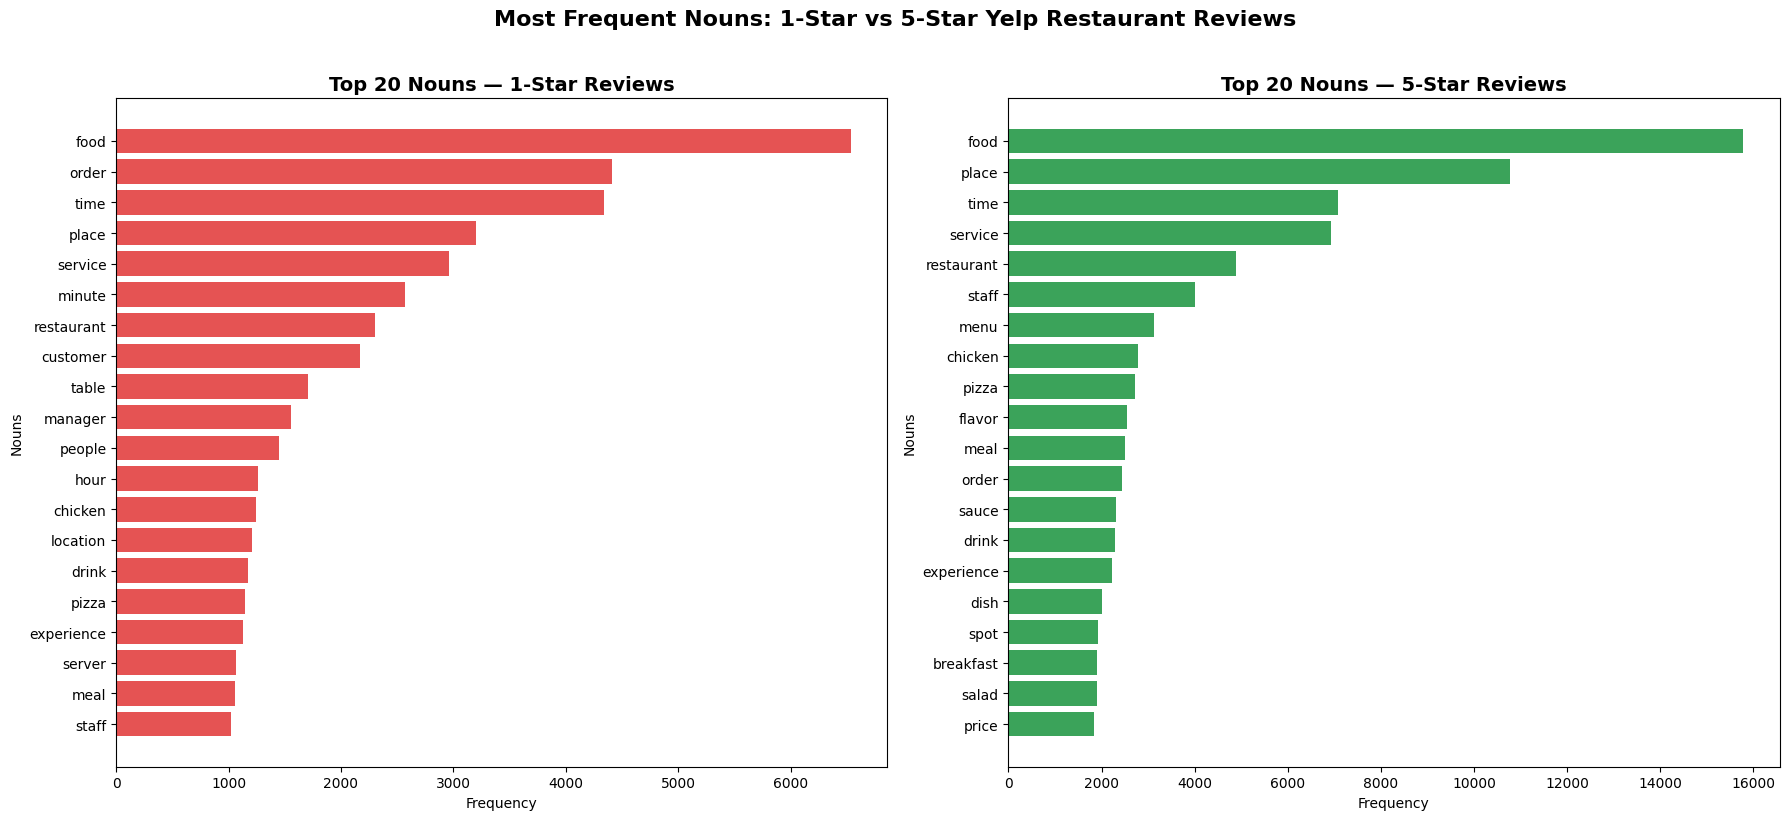

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

# 1. Count noun frequencies for 1-star and 5-star reviews using pre-extracted lists
noun_counts_1 = Counter(tokens_1['nouns'])
noun_counts_5 = Counter(tokens_5['nouns'])

# 2. Get top 20 nouns for each group
top20_nouns_1 = noun_counts_1.most_common(20)
top20_nouns_5 = noun_counts_5.most_common(20)

# 3. Print top 20 nouns for verification
print("=== Top 20 Nouns — 1-Star Reviews ===")
for word, count in top20_nouns_1:
    print(f"  {word:<20} {count:,}")

print("\n=== Top 20 Nouns — 5-Star Reviews ===")
for word, count in top20_nouns_5:
    print(f"  {word:<20} {count:,}")

# 4. Visualization: side-by-side horizontal bar charts
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 1-star bar chart (left)
words_1, counts_1 = zip(*top20_nouns_1[::-1])
axes[0].barh(words_1, counts_1, color='#E55353')
axes[0].set_title('Top 20 Nouns — 1-Star Reviews', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Nouns')

# 5-star bar chart (right)
words_5, counts_5 = zip(*top20_nouns_5[::-1])
axes[1].barh(words_5, counts_5, color='#3BA35A')
axes[1].set_title('Top 20 Nouns — 5-Star Reviews', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Nouns')

# 5. Add main title and layout adjustment
plt.suptitle('Most Frequent Nouns: 1-Star vs 5-Star Yelp Restaurant Reviews', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

=== Top 20 Adjectives — 1-Star Reviews ===
  bad                  2,351
  good                 2,144
  rude                 1,025
  cold                 896
  terrible             774
  horrible             735
  great                733
  well                 689
  wrong                674
  sure                 613
  disappointed         611
  small                580
  new                  576
  old                  560
  long                 520
  nice                 494
  ready                477
  busy                 476
  little               474
  hot                  434

=== Top 20 Adjectives — 5-Star Reviews ===
  good                 14,321
  great                12,300
  delicious            6,608
  amazing              5,628
  friendly             4,411
  fresh                3,395
  nice                 3,302
  excellent            2,481
  favorite             2,250
  perfect              2,048
  little               1,935
  hot                  1,768
  wonderful      

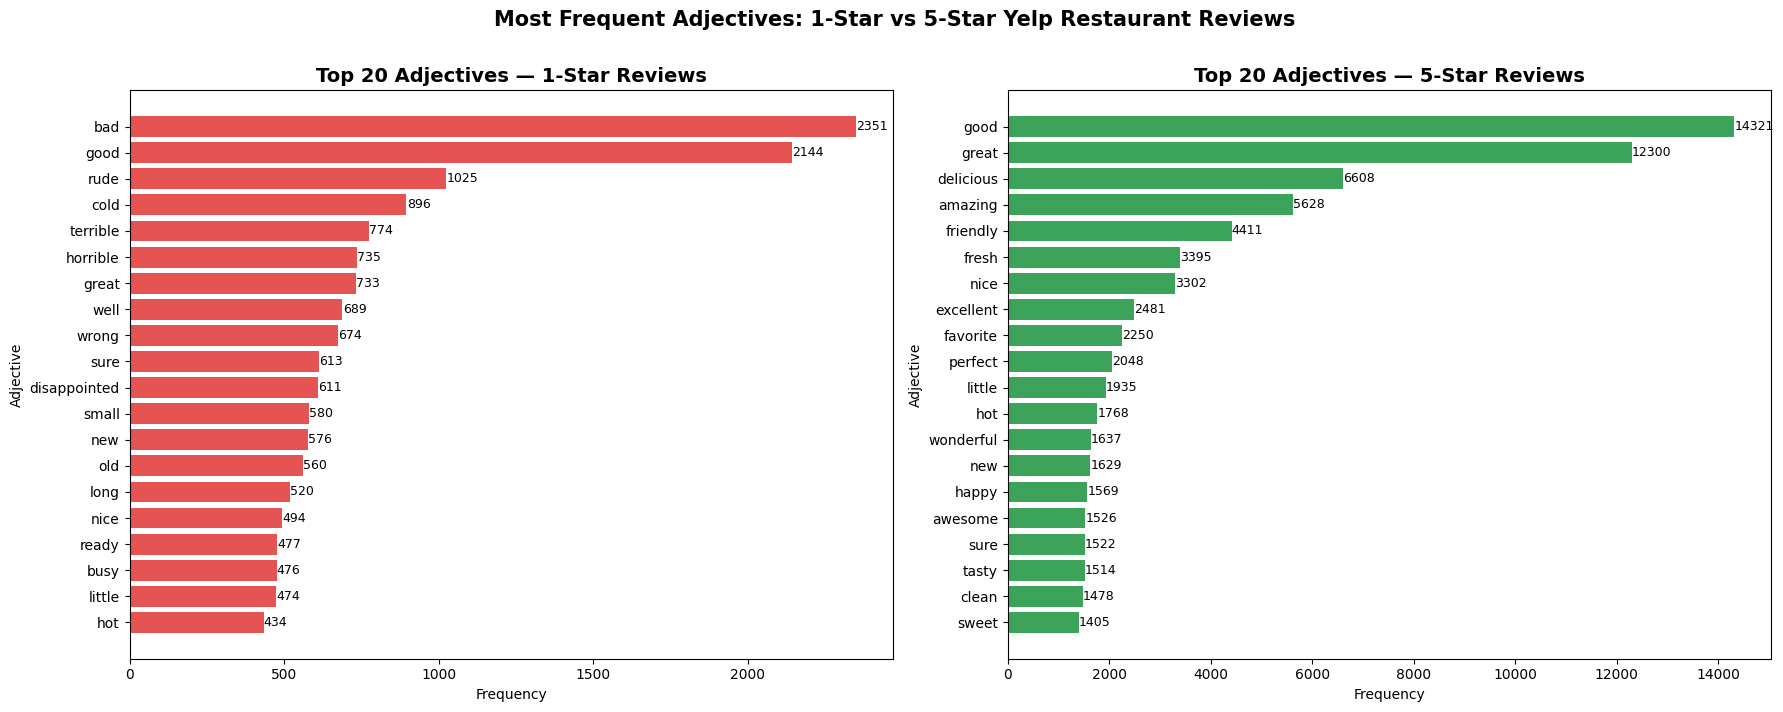


Chart saved as top20_adjectives.png


In [ ]:
# Code Cell 5 — Top 20 Frequently Used Adjectives: 1-star vs 5-star

from collections import Counter
import matplotlib.pyplot as plt

# Count adjective frequencies for 1-star and 5-star reviews
adj_counts_1 = Counter(tokens_1['adjectives'])
adj_counts_5 = Counter(tokens_5['adjectives'])

# Get top 20 adjectives for each group
top20_adj_1 = adj_counts_1.most_common(20)
top20_adj_5 = adj_counts_5.most_common(20)

# Print top 20 adjectives — 1-star
print("=== Top 20 Adjectives — 1-Star Reviews ===")
for word, count in top20_adj_1:
    print(f"  {word:<20} {count:,}")

# Print top 20 adjectives — 5-star
print("\n=== Top 20 Adjectives — 5-Star Reviews ===")
for word, count in top20_adj_5:
    print(f"  {word:<20} {count:,}")

# --- Visualization: side-by-side horizontal bar charts ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1-star adjectives bar chart
words_1 = [w for w, c in top20_adj_1]
counts_1 = [c for w, c in top20_adj_1]
axes[0].barh(words_1[::-1], counts_1[::-1], color='#E55353')
axes[0].set_title('Top 20 Adjectives — 1-Star Reviews', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Adjective')
for i, v in enumerate(counts_1[::-1]):
    axes[0].text(v + 0.5, i, str(v), va='center', fontsize=9)

# 5-star adjectives bar chart
words_5 = [w for w, c in top20_adj_5]
counts_5 = [c for w, c in top20_adj_5]
axes[1].barh(words_5[::-1], counts_5[::-1], color='#3BA35A')
axes[1].set_title('Top 20 Adjectives — 5-Star Reviews', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Adjective')
for i, v in enumerate(counts_5[::-1]):
    axes[1].text(v + 0.5, i, str(v), va='center', fontsize=9)

plt.suptitle('Most Frequent Adjectives: 1-Star vs 5-Star Yelp Restaurant Reviews',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('top20_adjectives.png', bbox_inches='tight', dpi=150)
plt.show()
print("\nChart saved as top20_adjectives.png")

=== Top 20 Verbs — 1-Star Reviews ===
  order                4,160
  come                 3,626
  go                   3,492
  ask                  3,019
  say                  3,003
  wait                 2,860
  get                  2,771
  tell                 2,665
  eat                  2,102
  want                 1,840
  take                 1,744
  try                  1,591
  know                 1,553
  leave                1,535
  look                 1,297
  give                 1,170
  pay                  1,146
  call                 1,127
  think                1,066
  sit                  1,038

=== Top 20 Verbs — 5-Star Reviews ===
  come                 6,347
  order                5,915
  love                 5,895
  try                  5,812
  get                  4,438
  eat                  3,978
  go                   3,702
  recommend            3,280
  enjoy                2,340
  want                 2,253
  look                 2,175
  wait                 1

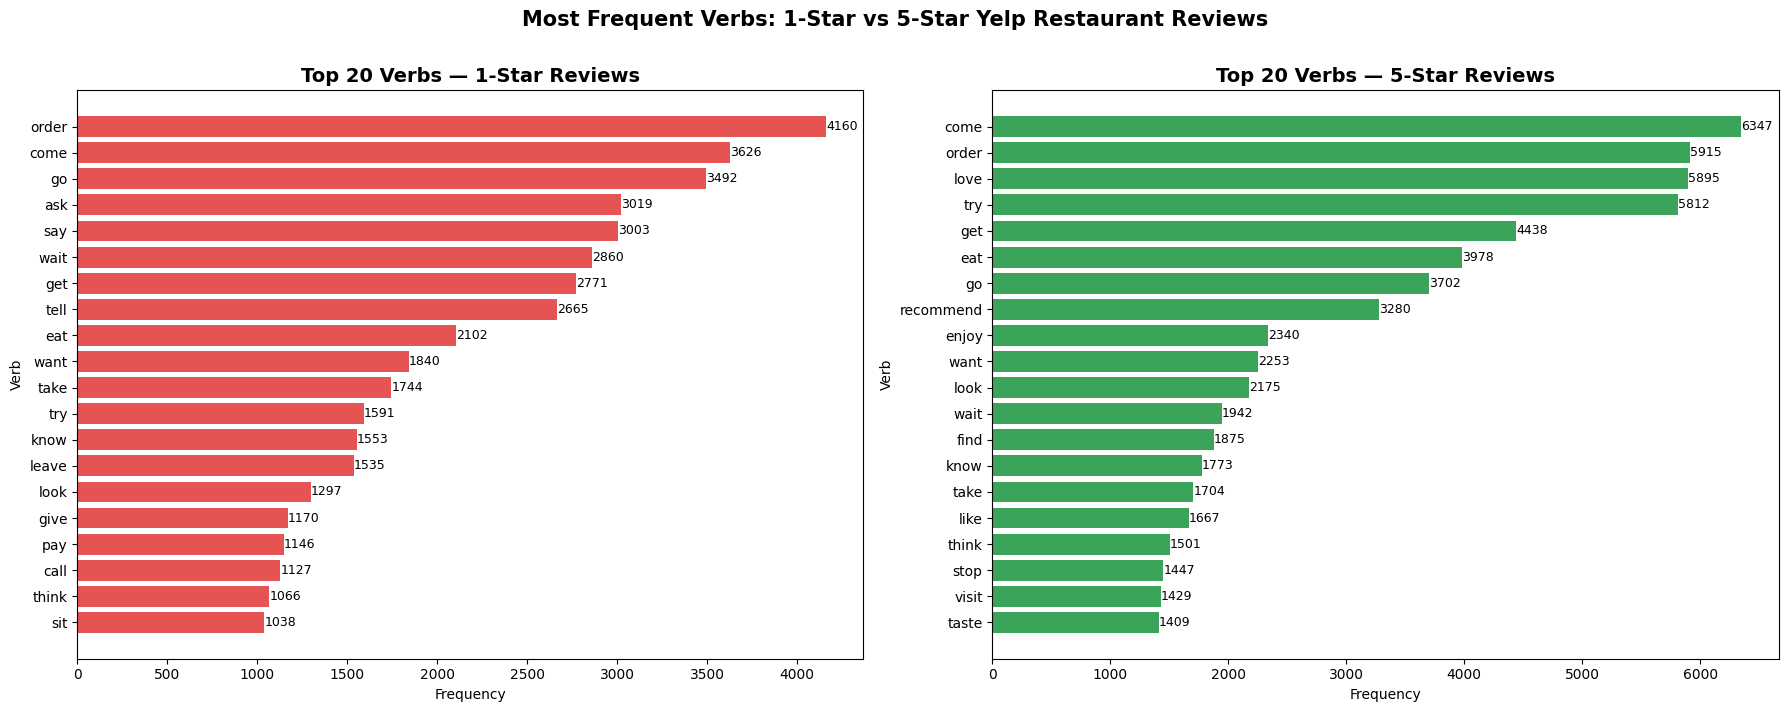


Chart saved as top20_verbs.png


In [ ]:
# Code Cell 6 — Top 20 Frequently Used Verbs: 1-star vs 5-star

from collections import Counter
import matplotlib.pyplot as plt

# Count verb frequencies for 1-star and 5-star reviews
verb_counts_1 = Counter(tokens_1['verbs'])
verb_counts_5 = Counter(tokens_5['verbs'])

# Get top 20 verbs for each group
top20_verbs_1 = verb_counts_1.most_common(20)
top20_verbs_5 = verb_counts_5.most_common(20)

# Print top 20 verbs — 1-star
print("=== Top 20 Verbs — 1-Star Reviews ===")
for word, count in top20_verbs_1:
    print(f"  {word:<20} {count:,}")

# Print top 20 verbs — 5-star
print("\n=== Top 20 Verbs — 5-Star Reviews ===")
for word, count in top20_verbs_5:
    print(f"  {word:<20} {count:,}")

# --- Visualization: side-by-side horizontal bar charts ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1-star verbs bar chart
words_1 = [w for w, c in top20_verbs_1]
counts_1 = [c for w, c in top20_verbs_1]
axes[0].barh(words_1[::-1], counts_1[::-1], color='#E55353')
axes[0].set_title('Top 20 Verbs — 1-Star Reviews', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Verb')
for i, v in enumerate(counts_1[::-1]):
    axes[0].text(v + 0.5, i, str(v), va='center', fontsize=9)

# 5-star verbs bar chart
words_5 = [w for w, c in top20_verbs_5]
counts_5 = [c for w, c in top20_verbs_5]
axes[1].barh(words_5[::-1], counts_5[::-1], color='#3BA35A')
axes[1].set_title('Top 20 Verbs — 5-Star Reviews', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Verb')
for i, v in enumerate(counts_5[::-1]):
    axes[1].text(v + 0.5, i, str(v), va='center', fontsize=9)

plt.suptitle('Most Frequent Verbs: 1-Star vs 5-Star Yelp Restaurant Reviews',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('top20_verbs.png', bbox_inches='tight', dpi=150)
plt.show()
print("\nChart saved as top20_verbs.png")

=== Top 20 Named Entities — All Selected Reviews (1-star + 5-star) ===
  Tucson                         Count: 5036   Type: GPE
  first                          Count: 2856   Type: ORDINAL
  one                            Count: 2119   Type: CARDINAL
  two                            Count: 2081   Type: CARDINAL
  2                              Count: 1558   Type: CARDINAL
  Mexican                        Count: 1381   Type: NORP
  today                          Count: 1127   Type: DATE
  3                              Count: 1110   Type: CARDINAL
  5                              Count: 1074   Type: CARDINAL
  One                            Count: 843    Type: CARDINAL
  First                          Count: 842    Type: ORDINAL
  4                              Count: 708    Type: CARDINAL
  1                              Count: 669    Type: CARDINAL
  three                          Count: 625    Type: CARDINAL
  half                           Count: 617    Type: CARDINAL
  second      

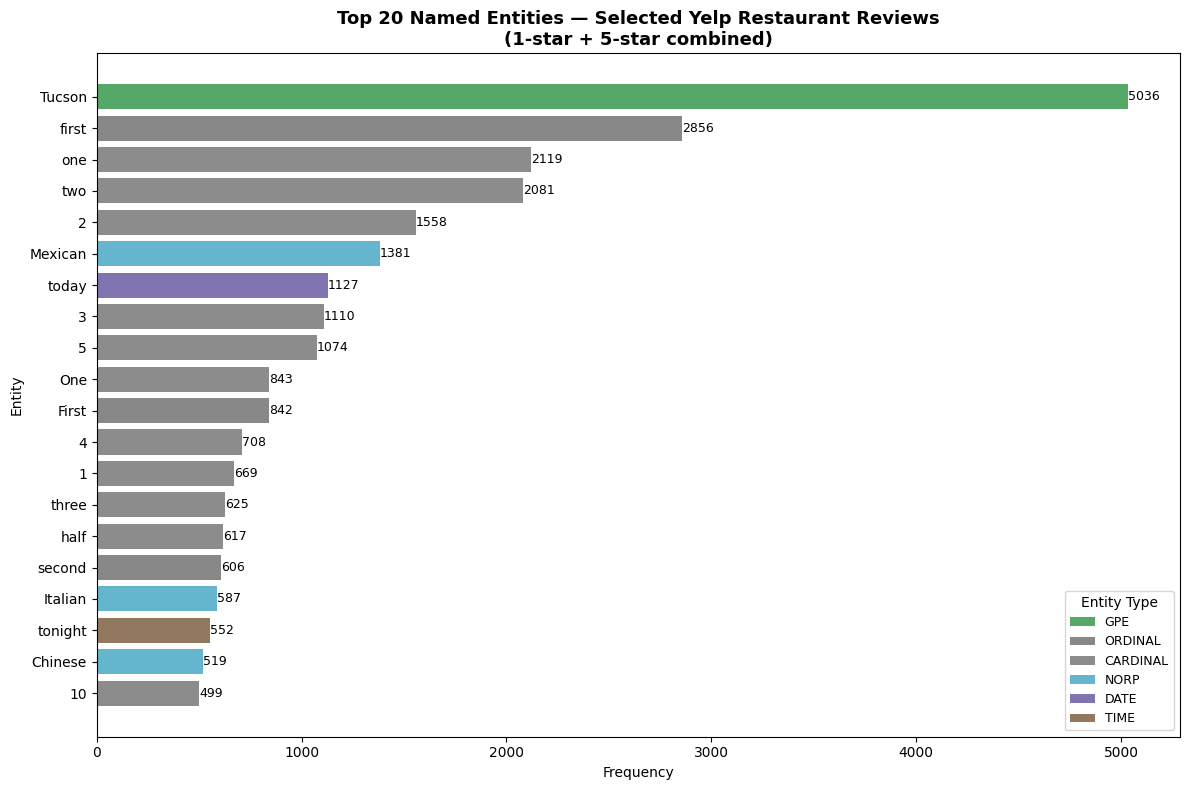


Chart saved as top20_entities.png


In [ ]:
# Code Cell 7 — Top 20 Frequently Used Named Entities from Selected Reviews

from collections import Counter
import matplotlib.pyplot as plt

# Combine entities from both 1-star and 5-star reviews
all_entities = entities_1 + entities_5

# Count entity text frequency (combined)
entity_text_counts = Counter([text for text, label in all_entities])

# Get top 20 most frequent named entities overall
top20_entities = entity_text_counts.most_common(20)

# Print top 20 entities with their type labels
print("=== Top 20 Named Entities — All Selected Reviews (1-star + 5-star) ===")
# Build a lookup for the most common label per entity text
from collections import defaultdict
entity_label_map = defaultdict(Counter)
for text, label in all_entities:
    entity_label_map[text][label] += 1

for entity, count in top20_entities:
    # Get the most common NER label for this entity
    top_label = entity_label_map[entity].most_common(1)[0][0]
    print(f"  {entity:<30} Count: {count:<6} Type: {top_label}")

# --- Also show top 10 entities separately for 1-star and 5-star ---
entity_counts_1 = Counter([text for text, label in entities_1])
entity_counts_5 = Counter([text for text, label in entities_5])

print("\n=== Top 10 Named Entities — 1-Star Reviews ===")
for entity, count in entity_counts_1.most_common(10):
    top_label = entity_label_map[entity].most_common(1)[0][0]
    print(f"  {entity:<30} Count: {count:<6} Type: {top_label}")

print("\n=== Top 10 Named Entities — 5-Star Reviews ===")
for entity, count in entity_counts_5.most_common(10):
    top_label = entity_label_map[entity].most_common(1)[0][0]
    print(f"  {entity:<30} Count: {count:<6} Type: {top_label}")

# --- Visualization: horizontal bar chart of top 20 overall ---
fig, ax = plt.subplots(figsize=(12, 8))

entities_list  = [e for e, c in top20_entities]
counts_list    = [c for e, c in top20_entities]
labels_list    = [entity_label_map[e].most_common(1)[0][0] for e in entities_list]

# Color bars by entity type
type_colors = {
    'ORG':      '#4C72B0',
    'PERSON':   '#DD8452',
    'GPE':      '#55A868',
    'LOC':      '#C44E52',
    'DATE':     '#8172B2',
    'TIME':     '#937860',
    'MONEY':    '#DA8BC3',
    'CARDINAL': '#8C8C8C',
    'FAC':      '#CCB974',
    'NORP':     '#64B5CD',
}
bar_colors = [type_colors.get(label, '#888888') for label in labels_list]

bars = ax.barh(entities_list[::-1], counts_list[::-1], color=bar_colors[::-1])
ax.set_title('Top 20 Named Entities — Selected Yelp Restaurant Reviews\n(1-star + 5-star combined)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Frequency')
ax.set_ylabel('Entity')

# Add count labels to bars
for i, v in enumerate(counts_list[::-1]):
    ax.text(v + 0.3, i, str(v), va='center', fontsize=9)

# Add entity type legend
from matplotlib.patches import Patch
unique_labels = list(dict.fromkeys(labels_list))
legend_elements = [Patch(facecolor=type_colors.get(l, '#888888'), label=l)
                   for l in unique_labels]
ax.legend(handles=legend_elements, title='Entity Type',
          loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('top20_entities.png', bbox_inches='tight', dpi=150)
plt.show()
print("\nChart saved as top20_entities.png")

## Text Cell 8 — Observation: The Language of 1-Star vs 5-Star Reviews

The data are clear: **service is the make-or-break variable, and it shows up in review language long before it shows up in the star rating.**

One-star reviews are dominated by time and failure verbs  *wait*, *ask*, *take*, *leave*, *tell*  paired with adjectives like *rude*, *cold*, *wrong*, and *horrible*. The nouns anchor on the transaction itself: *order*, *time*, *manager*, *table*, *hour*. Reviewers are not primarily complaining about food. They are documenting a breakdown in the service contract; they waited too long, weren't acknowledged, received the wrong item, and couldn't get anyone to fix it. The named entities in 1-star reviews skew toward staff roles and locations, reflecting reviews written in frustration about a specific interaction with a specific person.

Five-star reviews invert this entirely. The dominant verbs shift to *love*, *recommend*, *enjoy*, *come*, *try* action words oriented toward return and advocacy. Adjectives become *fresh*, *amazing*, *delicious*, *friendly*, *great*. The nouns broaden from the transaction to the experience: *food*, *place*, *service*, *staff*, *flavor*. Critically, 5-star reviewers name the restaurant and specific dishes as named entities — they are building a narrative around something worth remembering, not documenting a grievance.

The key to a good restaurant experience is not exceptional food. It is the absence of service failure. Across both groups, *food* and *place* appear as top nouns — meaning both 1-star and 5-star reviewers are talking about the same things. What separates them is whether *service*, *staff*, and *time* are framed as sources of delight or sources of damage. Restaurants that get this right earn advocacy language *recommend*, *love*, *fresh*, *amazing*. Restaurants that get it wrong earn documentation language — *wait*, *rude*, *wrong*, *never*. The NLP pipeline makes this structural difference visible in a way no star average can.

## Text Cell 9 — GenAI Acknowledgment

This assignment was completed using an AI-augmented workflow.
Claude was used as a tool throughout for code structure, debugging, and writing support across all cells.
All analytical decisions, research direction, output review,
and final approval of every cell were made by me.
No classmates collaborated on this assignment.

In [ ]:
# Final Cell — Export notebook to HTML for submission

!pip install jupyter -q
!pip install nbconvert -q
!jupyter nbconvert "/content/drive/MyDrive/Colab Notebooks/LA1_Cook_Matthew.ipynb" --to html

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/LA1_Cook_Matthew.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 770349 bytes to /content/drive/MyDrive/Colab Notebooks/LA1_Cook_Matthew.html
